In [2]:
from PIL import Image, ImageDraw, ImageFont

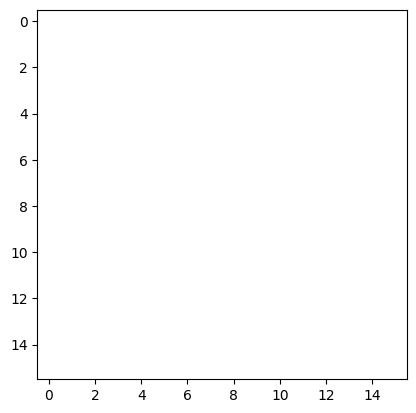

In [4]:
from matplotlib import pyplot as plt
canvas = Image.new('RGB', (16, 16), color='white')
canvas.save("small_canvas.png","png")
plt.imshow(canvas)

184.37421875


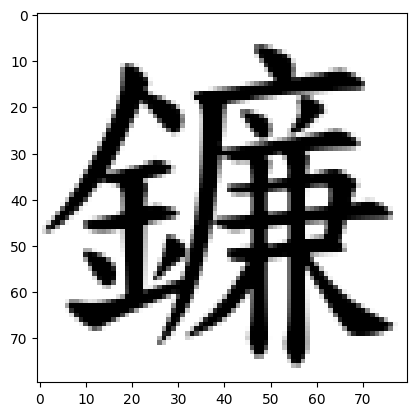

In [6]:
import numpy as np

img = Image.open('canvas.png')
drawtext = ImageDraw.Draw(img)
font = ImageFont.truetype('kaiu.ttf', 80)
drawtext.text((0,0), "鐮", font=font, fill=(0,0,0))
plt.imshow(img)
# img.save("test.png")

print(np.average(img))

In [8]:
with open("characters.txt", 'r', encoding='UTF-8') as file:
    characters = file.readlines()

font = ImageFont.truetype('kaiu.ttf', 16)
with open("character_density_16px.txt", 'w') as file:
    for char in characters:
        img = Image.open('small_canvas.png')
        drawtext = ImageDraw.Draw(img)
        drawtext.text((0,0), char, font=font, fill=(0,0,0))
        file.write(str(np.average(img))+'\n')


In [9]:
with open("character_density_16px.txt", 'r') as file:
    sorted_density = file.readlines()

density = sorted_density.copy()
sorted_density.sort()
print(f"Min visual brightness: {sorted_density[0].strip()} at {density.index(sorted_density[0])}")   # 一
print(f"Max visual brightness: {sorted_density[-1].strip()} at {density.index(sorted_density[-1])}") # 鐮

Min visual brightness: 180.828125 at 4351
Max visual brightness: 243.10546875 at 0


In [19]:
def get_index(char):
    return density[characters.index(char)]
out = sorted(characters, key=get_index)
with open("characters_sorted_by_lightness.txt", 'w', encoding='UTF-8') as file:
    for char in out:
        file.write(char)

(array([378., 448., 509., 565., 546., 538., 526., 490., 431., 377.]),
 array([   0.,  348.,  696., 1044., 1392., 1740., 2088., 2436., 2784.,
        3132., 3480.]),
 <BarContainer object of 10 artists>)

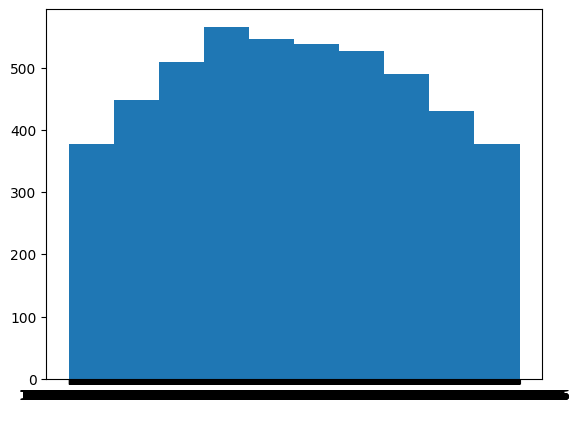

In [10]:
plt.hist(sorted_density, label=None)